--- Benchmarking 11-Node Network ---
T0: 1000  | Converged Distance: 1894.00
T0: 100   | Converged Distance: 2084.00
T0: 10    | Converged Distance: 2104.00
T0: 1     | Converged Distance: 2154.00

--- Benchmarking 48-Node Network ---
T0: 10000 | Converged Distance: 14132.00
T0: 1000  | Converged Distance: 13776.00
T0: 100   | Converged Distance: 15361.00


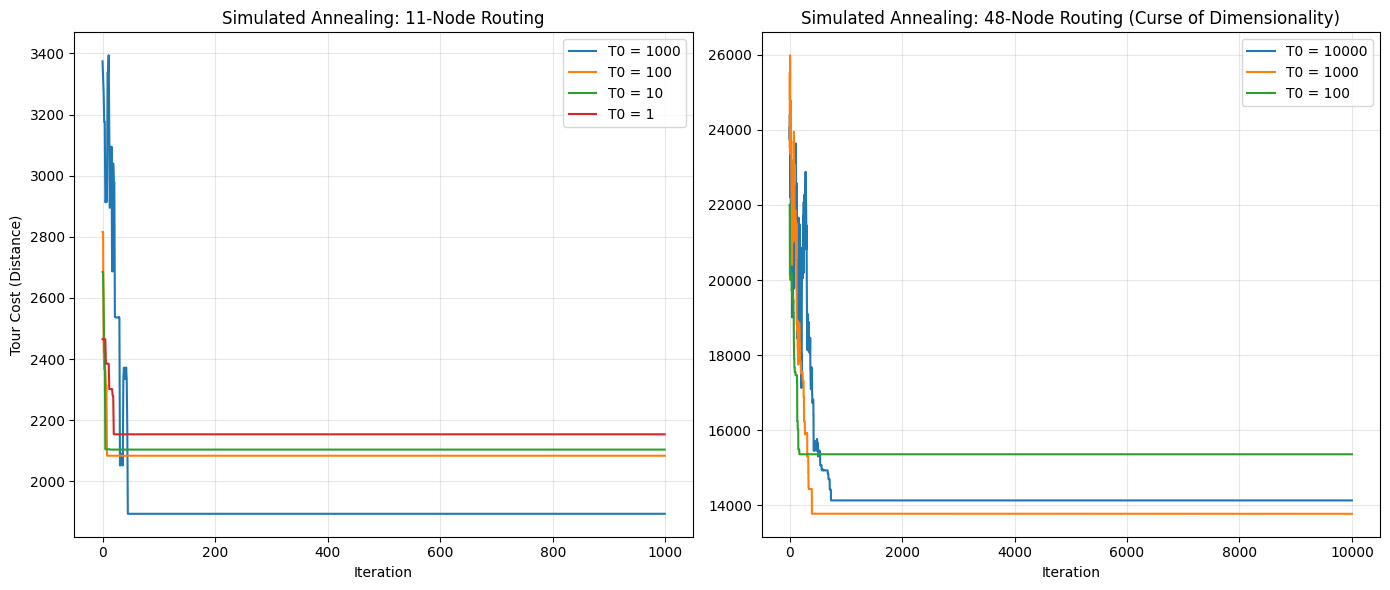

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import pandas as pd

# ==========================================
# 1. Exact Topological Validation (DFJ Polytope)
# ==========================================
def check_extreme_point(edge_vector):
    """Checks if an |E| dimensional 0-1 vector is an extreme point of the TSP polytope."""
    E_len = len(edge_vector)
    n = int((1 + math.sqrt(1 + 8 * E_len)) / 2)

    if n * (n - 1) // 2 != E_len: return False

    adj = {i: [] for i in range(n)}
    idx, selected_edges_count = 0, 0

    for i in range(n):
        for j in range(i + 1, n):
            if edge_vector[idx] == 1:
                adj[i].append(j)
                adj[j].append(i)
                selected_edges_count += 1
            idx += 1

    # Check 1: Must have exactly n edges
    if selected_edges_count != n: return False

    # Check 2: Degree Constraint (Every city must have exactly 2 edges)
    for i in range(n):
        if len(adj[i]) != 2: return False

    # Check 3: Sub-tour Elimination (Must be a single connected loop)
    visited = set()
    def dfs(curr):
        visited.add(curr)
        for neighbor in adj[curr]:
            if neighbor not in visited:
                dfs(neighbor)
    dfs(0)

    return len(visited) == n

# ==========================================
# 2. Simulated Annealing Engine
# ==========================================
def cost(tour, dist_matrix):
    return sum(dist_matrix[tour[i]][tour[(i + 1) % len(tour)]] for i in range(len(tour)))

def neighbour(tour):
    new_tour = tour.copy()
    n = len(tour)
    idx = random.randint(0, n - 1)
    next_idx = (idx + 1) % n
    new_tour[idx], new_tour[next_idx] = new_tour[next_idx], new_tour[idx]
    return new_tour

def accept_prob(c_old, c_new, T):
    if c_new <= c_old: return 1.0
    return math.exp(-(c_new - c_old) / T)

def simulated_annealing(dist_matrix, T0, alpha, max_iter):
    n_cities = dist_matrix.shape[0]
    current_tour = list(range(n_cities))
    random.shuffle(current_tour)
    current_cost = cost(current_tour, dist_matrix)

    best_tour, best_cost = current_tour.copy(), current_cost
    cost_history = []
    T = T0

    for _ in range(max_iter):
        new_tour = neighbour(current_tour)
        new_cost = cost(new_tour, dist_matrix)

        if random.random() < accept_prob(current_cost, new_cost, T):
            current_tour, current_cost = new_tour, new_cost

        if current_cost < best_cost:
            best_tour, best_cost = current_tour.copy(), current_cost

        cost_history.append(current_cost)
        T *= alpha

    return best_tour, best_cost, cost_history

# ==========================================
# 3. Execution & Benchmarking
# ==========================================
# Load 11-City Network
dist_matrix_11 = pd.read_csv('TSP11.csv', index_col=0).values

print("--- Benchmarking 11-Node Network ---")
T0_values = [1000, 100, 10, 1]
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for T0 in T0_values:
    best_route, best_distance, history = simulated_annealing(dist_matrix_11, T0, 0.95, 1000)
    plt.plot(history, label=f'T0 = {T0}')
    print(f"T0: {T0:<5} | Converged Distance: {best_distance:.2f}")

plt.title('Simulated Annealing: 11-Node Routing')
plt.xlabel('Iteration')
plt.ylabel('Tour Cost (Distance)')
plt.legend()
plt.grid(True, alpha=0.3)

# Load 48-City Network
dist_matrix_48 = pd.read_csv('TSP48.csv', index_col=0).values

print("\n--- Benchmarking 48-Node Network ---")
T0_values_48 = [10000, 1000, 100]
plt.subplot(1, 2, 2)
for T0 in T0_values_48:
    best_route, best_distance, history = simulated_annealing(dist_matrix_48, T0, 0.99, 10000)
    plt.plot(history, label=f'T0 = {T0}')
    print(f"T0: {T0:<5} | Converged Distance: {best_distance:.2f}")

plt.title('Simulated Annealing: 48-Node Routing (Curse of Dimensionality)')
plt.xlabel('Iteration')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()